In [38]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [39]:
df =pd.read_csv('products_all_fixed.csv')

print(f"Total rows: {len(df):,}")
print(f"Total columns:{len(df.columns)}")
print(f"Categories:{list(df['category'].unique())}")
print(f"Sellers:{list(df['seller'].unique())}")
print(f"Unique products:{df['product_name'].nunique()}")
print(f"\nColumn names:{list(df.columns)}")
df.head()

Total rows: 58,000
Total columns:8
Categories:['Personal Care', 'Food & Beverages', 'Cosmetics', 'Household', 'Sports']
Sellers:['SastoDeal', 'Daraz Nepal', 'Amazon', 'HamroBazar']
Unique products:237

Column names:['product_id', 'product_name', 'brand', 'category', 'subcategory', 'seller', 'price_NPR', 'currency']


,product_id,product_name,brand,category,subcategory,seller,price_NPR,currency
0,P0001,Dove Shampoo 500ml,Dove,Personal Care,Shampoo,SastoDeal,770.86,NPR
1,P0002,Dove Shampoo 500ml,Dove,Personal Care,Shampoo,Daraz Nepal,911.60,NPR
2,P0003,Dove Shampoo 500ml,Dove,Personal Care,Shampoo,Amazon,658.87,NPR
3,P0004,Dove Shampoo 500ml,Dove,Personal Care,Shampoo,HamroBazar,660.83,NPR
4,P0005,Dove Shampoo 200ml,Dove,Personal Care,Shampoo,SastoDeal,462.33,NPR


In [40]:
print("Basic Statistics\n")

print(df['price_NPR'].describe().round(2))
print(f"\nMost expensive product : {df.loc[df['price_NPR'].idxmax(), 'product_name']} — NPR {df['price_NPR'].max():,.2f}")
print(f"Cheapest product:{df.loc[df['price_NPR'].idxmin(), 'product_name']} — NPR {df['price_NPR'].min():,.2f}")
print(f"Average price:NPR{df['price_NPR'].mean():,.2f}")

Basic Statistics

count    58000.00
mean       931.93
std        932.77
min         38.53
25%        366.91
50%        667.26
75%       1126.21
max       6795.92
Name: price_NPR, dtype: float64

Most expensive product : Optimum Nutrition Whey 1kg — NPR 6,795.92
Cheapest product:Wai Wai Chicken 75g — NPR 38.53
Average price:NPR931.93


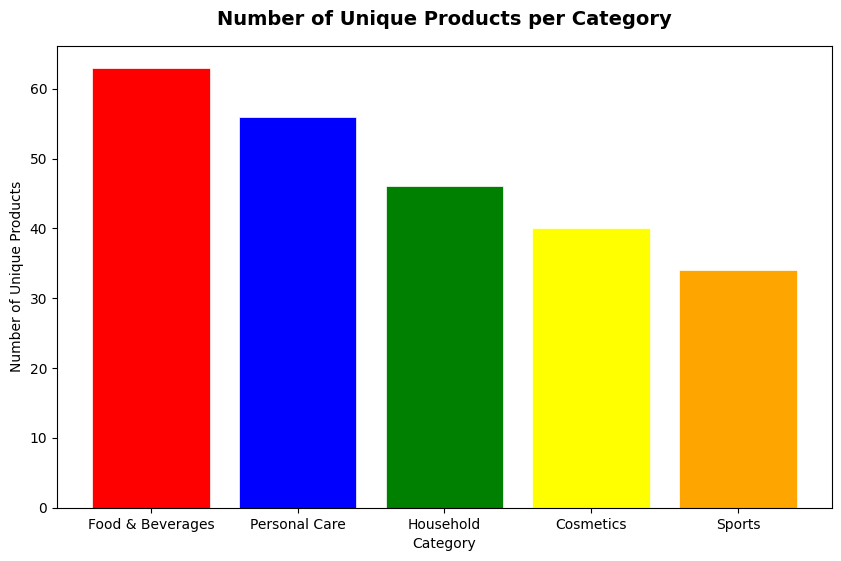

Saved: chart1_products_per_category.png


In [41]:
category_counts = df.groupby('category')['product_name'].nunique().sort_values(ascending=False)

fig,ax=plt.subplots(figsize=(10, 6))
bars = ax.bar(category_counts.index, category_counts.values,
              color=['red','blue','green','yellow','orange'],
              edgecolor='white',linewidth=0.5)

ax.set_title('Number of Unique Products per Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category')
ax.set_ylabel('Number of Unique Products')
plt.savefig('chart1_products_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_products_per_category.png")


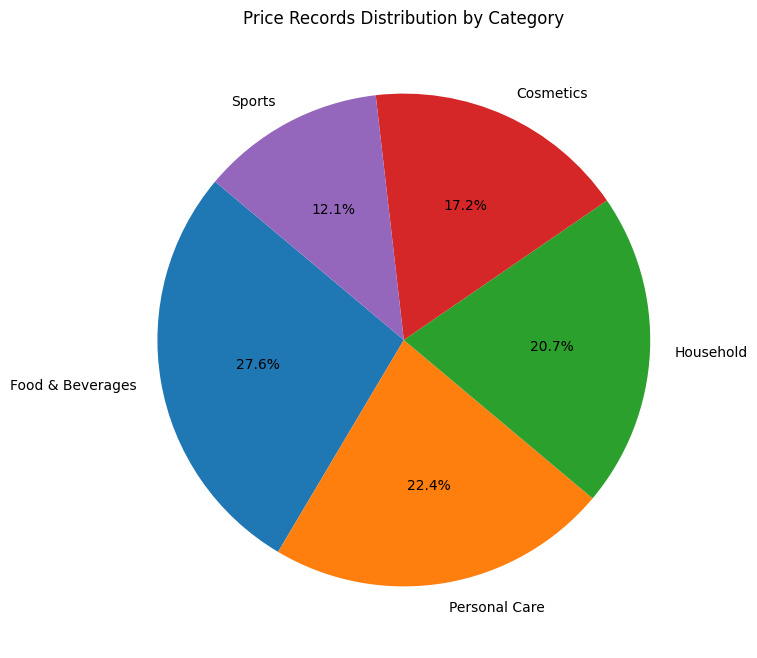

Saved: chart2_records_distribution.png


In [42]:
row_counts = df["category"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    row_counts,
    labels=row_counts.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Price Records Distribution by Category")
plt.savefig("chart2_records_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: chart2_records_distribution.png")

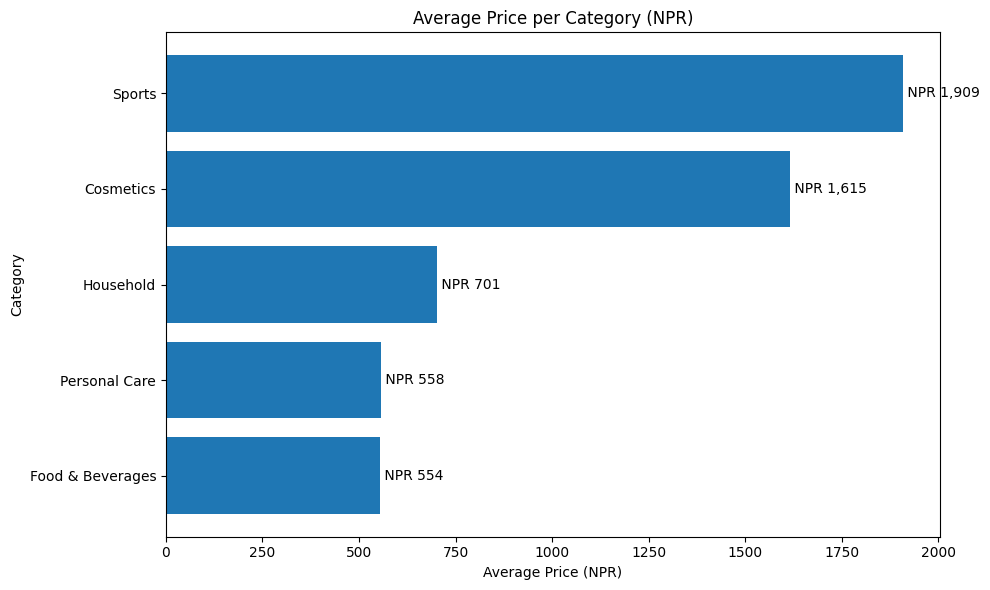

Saved: chart3_avg_price_per_category.png


In [43]:
avg_price = df.groupby("category")["price_NPR"].mean().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(avg_price.index, avg_price.values)

for bar, val in zip(bars, avg_price.values):
    plt.text(val, bar.get_y() + bar.get_height() / 2, f" NPR {val:,.0f}", va="center")

plt.title("Average Price per Category (NPR)")
plt.xlabel("Average Price (NPR)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("chart3_avg_price_per_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: chart3_avg_price_per_category.png")

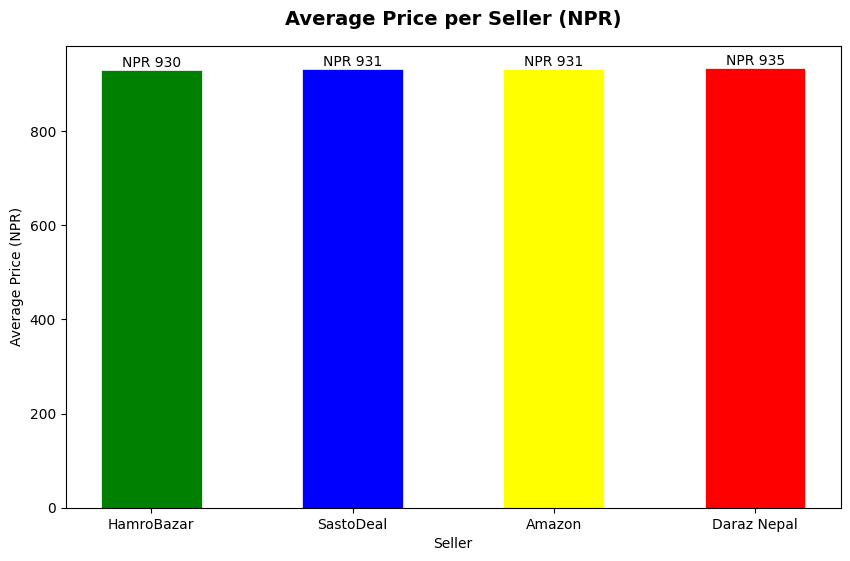

Saved: chart4_price_per_seller.png


In [44]:
seller_avg = df.groupby('seller')['price_NPR'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(seller_avg.index, seller_avg.values,
              color=['green','blue','yellow','red'],
              edgecolor='white', linewidth=0.5, width=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"NPR {h:,.0f}",
        ha="center",
        va="bottom"
    )


ax.set_title('Average Price per Seller (NPR)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Seller')
ax.set_ylabel('Average Price (NPR)')
plt.savefig('chart4_price_per_seller.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_price_per_seller.png")

C:\Users\Hp\AppData\Local\Temp\ipykernel_17252\1153788794.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=categories, patch_artist=True)


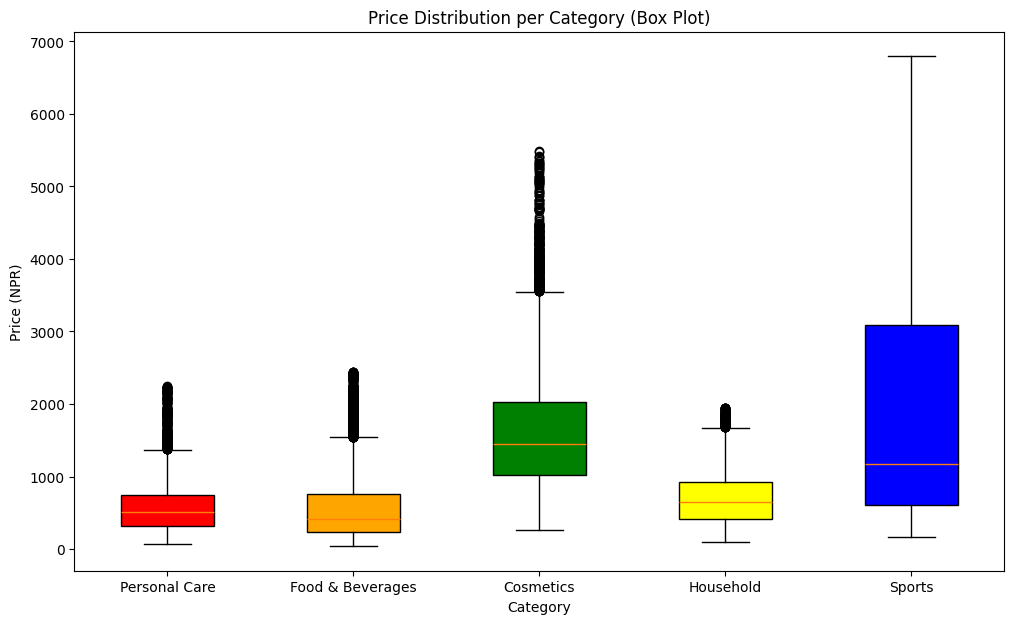

Saved: chart5_price_distribution.png


In [45]:
fig, ax = plt.subplots(figsize=(12, 7))

categories = df["category"].unique()
data_by_cat = [df[df["category"] == cat]["price_NPR"] for cat in categories]

bp = ax.boxplot(data_by_cat, labels=categories, patch_artist=True)

colors = ["red", "orange", "green", "yellow", "blue"]
for box, c in zip(bp["boxes"], colors):
    box.set_facecolor(c)

ax.set_title("Price Distribution per Category (Box Plot)")
ax.set_xlabel("Category")
ax.set_ylabel("Price (NPR)")


plt.savefig("chart5_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: chart5_price_distribution.png")

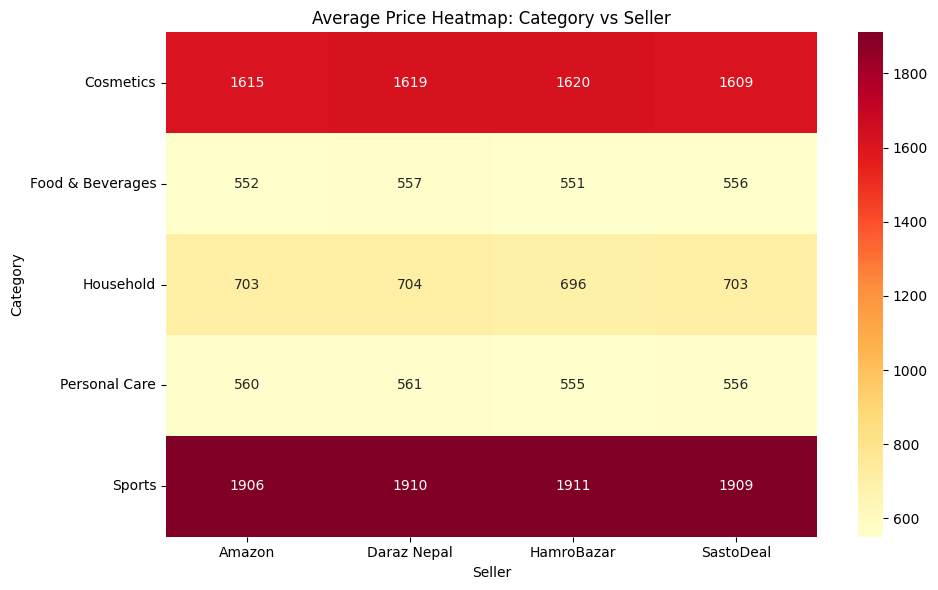

Saved: chart6_heatmap.png


In [46]:
pivot = df.pivot_table(index="category", columns="seller", values="price_NPR", aggfunc="mean")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Average Price Heatmap: Category vs Seller")
plt.xlabel("Seller")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("chart6_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: chart6_heatmap.png")

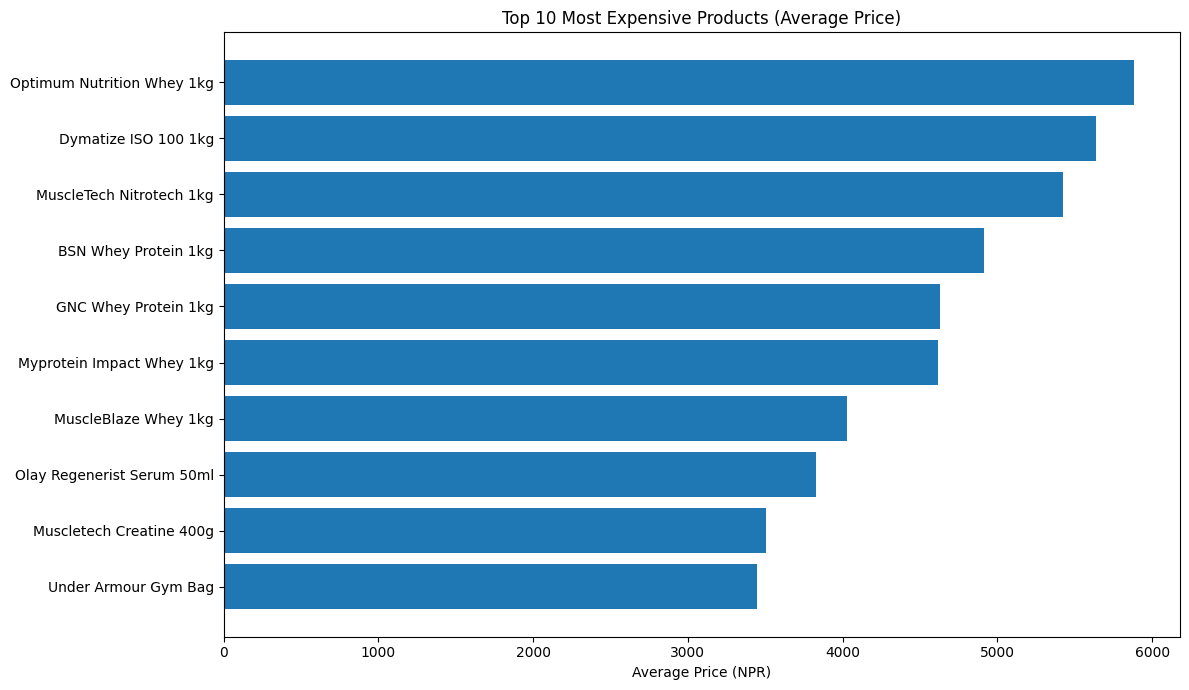

Saved: chart7_top10_expensive.png


In [47]:
top10 = (
    df.groupby("product_name")["price_NPR"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))
plt.barh(top10.index, top10.values)
plt.gca().invert_yaxis()

plt.title("Top 10 Most Expensive Products (Average Price)")
plt.xlabel("Average Price (NPR)")
plt.tight_layout()

plt.savefig("chart7_top10_expensive.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: chart7_top10_expensive.png")

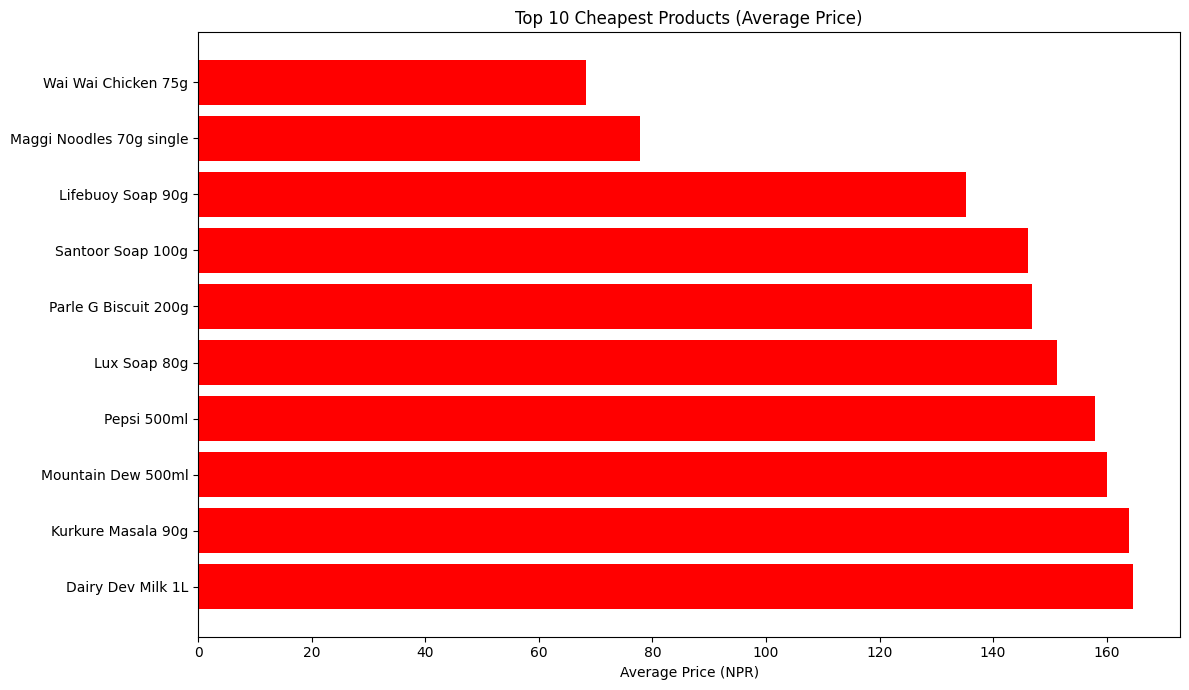

Saved:chart8_top10_cheapest.png


In [48]:
bottom10 = (
    df.groupby("product_name")["price_NPR"]
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12, 7))
plt.barh(bottom10.index, bottom10.values, color="red")
plt.gca().invert_yaxis()

plt.title("Top 10 Cheapest Products (Average Price)")
plt.xlabel("Average Price (NPR)")
plt.tight_layout()

plt.savefig("chart8_top10_cheapest.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:chart8_top10_cheapest.png")